## The Nobel Prize

...has been among the most prestigious international awards since 1901. Each year, awards are bestowed in chemistry, literature, physics, physiology or medicine, economics, and peace. In addition to the honor, prestige, and substantial prize money, the recipient also gets a gold medal with an image of Alfred Nobel (1833 - 1896), who established the prize.

![](../images/Nobel_Prize.png)

The Nobel Foundation has made a dataset available of all prize winners from the outset of the awards from 1901 to 2023. The dataset used in this project is from the Nobel Prize API and is available in the `nobel.csv` file in the `data` folder.

In this project, we'll explore and answer several questions related to this prizewinning data.

In [1]:
# Loading in required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# read the data file, check columns and inspect 1st few records
df_nobel = pd.read_csv('../data/nobel.csv')
print(f"Shape of df_nobel: {df_nobel.shape}\n")
print(df_nobel.columns, '\n')
df_nobel.head()

Shape of df_nobel: (1000, 18)

Index(['year', 'category', 'prize', 'motivation', 'prize_share', 'laureate_id',
       'laureate_type', 'full_name', 'birth_date', 'birth_city',
       'birth_country', 'sex', 'organization_name', 'organization_city',
       'organization_country', 'death_date', 'death_city', 'death_country'],
      dtype='object') 



,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


## What is the most commonly awarded gender?

No big suprises here, but what is interesting is the magnitude of the difference.

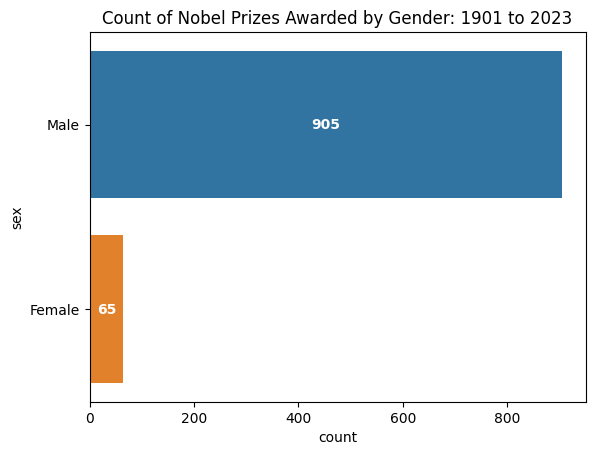

The gender with the most Nobel Prizes is : Male with 905 prize count


In [2]:
# need to rename the count series before resetting index to avoid name collision
df_sex = df_nobel.groupby(by='sex')['sex'].count().rename('count').reset_index()
df_sex = df_sex.sort_values(by='sex', ascending=False)
ax = sns.barplot(data=df_sex, x='count', y='sex', hue='sex')
# add the counts to the bars
for cont in ax.containers:
    ax.bar_label(cont, label_type='center', color='white', fontweight='bold')
# add title
ax.set_title("Count of Nobel Prizes Awarded by Gender: 1901 to 2023")
plt.show()

top_gender = df_sex.iloc[0, 0]  # top gender is 1st tuple in list
print(f"The gender with the most Nobel Prizes is : {top_gender} with {df_sex.iloc[0, 1]} prize count")

## What are the most commonly awarded birth countries?

What makes this a little ticky is the fact that country borders and designations have shifted since 1901. The listed birth countries were written out and a mapping was created in the file `country_mapping.csv`. This file was then used to consolidate the number of `birth_country` listings.

In [3]:
pd.set_option('display.max_rows', None)
country_counts = df_nobel['birth_country'].value_counts().sort_index()
country_counts.to_csv('country_counts.csv')  # write out countries to create mapping off-line
print(country_counts[:10])                   # can see the issue in the first 10 listings

birth_country
Argentina                                    4
Australia                                   10
Austria                                     16
Austria-Hungary (Austria)                    1
Austria-Hungary (Bosnia and Herzegovina)     1
Austria-Hungary (Croatia)                    1
Austria-Hungary (Czech Republic)             4
Austria-Hungary (Hungary)                    3
Austria-Hungary (Poland)                     1
Austria-Hungary (Slovenia)                   1
Name: count, dtype: int64


In [4]:
# read in the list and create a dict to make the mapping easier
df_country_mapping = pd.read_csv('country_mapping.csv')
country_mapping_dict = dict(zip(df_country_mapping['original_birth_country'], df_country_mapping['mapped_country']))
# update the countries to the new mapped values
df_nobel['contemporary_country'] = df_nobel['birth_country'].map(country_mapping_dict)
# check a few of the changed rows
df_nobel.loc[[2,5,6,7,15,19], ['year', 'category', 'full_name', 'birth_country', 'contemporary_country']]

,year,category,full_name,birth_country,contemporary_country
2,1901,Medicine,Emil Adolf von Behring,Prussia (Poland),Poland
5,1901,Physics,Wilhelm Conrad Röntgen,Prussia (Germany),Germany
6,1902,Chemistry,Hermann Emil Fischer,Prussia (Germany),Germany
7,1902,Literature,Christian Matthias Theodor Mommsen,Schleswig (Germany),Germany
15,1903,Medicine,Niels Ryberg Finsen,Faroe Islands (Denmark),Denmark
19,1903,Physics,"Marie Curie, née Sklodowska",Russian Empire (Poland),Poland


In [5]:
# check the country counts before and after consolidation
print(f"There were {country_counts.shape[0]} birth countries listings BEFORE consolidation.")
print(f"\nThere were {df_nobel['contemporary_country'].nunique()} birth countries listings AFTER consolidation.")

There were 129 birth countries listings BEFORE consolidation.

There were 84 birth countries listings AFTER consolidation.


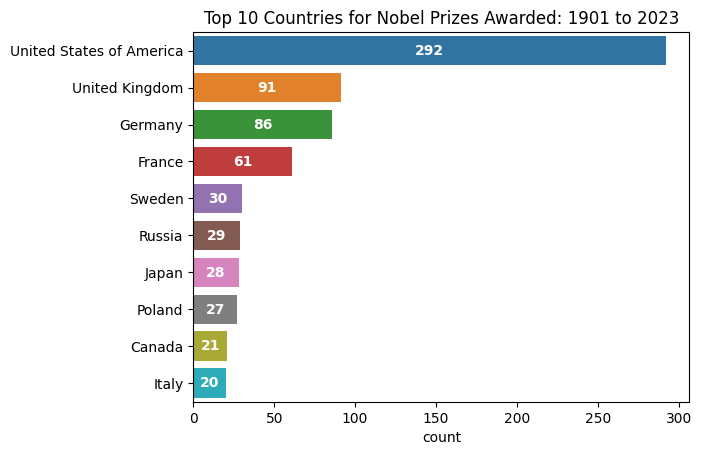

The country with the most Nobel Prizes is : United States of America with 292


In [6]:
# visualize the top 10
df_top_10_countries_awarded = pd.DataFrame(df_nobel['contemporary_country'].value_counts()[:10]).reset_index()
ax = sns.barplot(data=df_top_10_countries_awarded, x='count', y='contemporary_country',
                 hue='contemporary_country')
# add the counts to the bars
for cont in ax.containers:
    ax.bar_label(cont, label_type='center', color='white', fontweight='bold')
# add title
ax.set_title("Top 10 Countries for Nobel Prizes Awarded: 1901 to 2023")
# don't need ylabel
ax.set_ylabel("")
plt.show()

top_country = df_top_10_countries_awarded.iloc[0, 0]
top_country_count = df_top_10_countries_awarded.iloc[0, 1]
print(f"The country with the most Nobel Prizes is : {top_country} with {top_country_count}")

## Which decade had the highest ratio of US-born Nobel Prize winners to total winners in all categories?


In [7]:
# only use columns needed for this section
df_over_time = df_nobel.loc[:, ["year", "contemporary_country", "category"]]
df_over_time = df_over_time.sort_values(by=["year", "contemporary_country"])
# create decade column
df_over_time['decade'] = df_over_time["year"].astype(str).str[:3] + "0"
# shorten the country column name
df_over_time = df_over_time.rename(columns={"contemporary_country": "country"})
df_over_time['is_USA'] = df_over_time['country'].apply(lambda c: 1 if c == "United States of America" else 0)
df_over_time.sort_values(by=['year', 'category'], inplace=True)
print(f"Shape of df_over_time: {df_over_time.shape}\n")
# check out new is_USA column
df_over_time.loc[df_over_time['country'] == "United States of America", :].head()

Shape of df_over_time: (1000, 5)



,year,country,category,decade,is_USA
35,1906,United States of America,Peace,1900,1
72,1912,United States of America,Peace,1910,1
79,1914,United States of America,Chemistry,1910,1
95,1919,United States of America,Peace,1910,1
117,1923,United States of America,Physics,1920,1


In [8]:
# create counts of non-US and US awards by decade
df_medals_by_decade = df_over_time.groupby(by=['decade', 'is_USA'])['is_USA'].count()
df_medals_by_decade = df_medals_by_decade.rename('count').reset_index()
df_medals_by_decade = df_medals_by_decade.pivot(index='decade', columns='is_USA', values='count').reset_index()
df_medals_by_decade.columns.name = None  # is_USA is the column axis name (not the index name)
# rename country count columns to something more readable
df_medals_by_decade.rename(columns={0: "Other", 1: "USA"}, inplace=True)
# proportion USA awards
df_medals_by_decade['total_awards'] = df_medals_by_decade['Other'] + df_medals_by_decade['USA']
df_medals_by_decade['USA_prop'] = df_medals_by_decade['USA'] / df_medals_by_decade['total_awards']
df_medals_by_decade.head()

,decade,Other,USA,total_awards,USA_prop
0,1900,56,1,57,0.017544
1,1910,37,3,40,0.075000
2,1920,50,4,54,0.074074
3,1930,42,14,56,0.250000
4,1940,30,13,43,0.302326


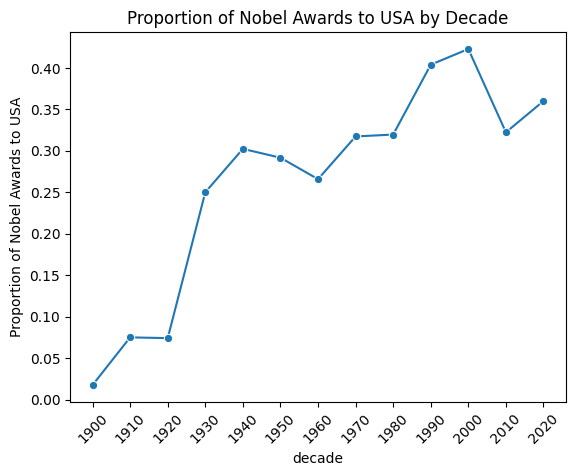

In [9]:
g = sns.lineplot(data=df_medals_by_decade, x="decade", y="USA_prop", marker='o')
g.set_ylabel("Proportion of Nobel Awards to USA")
g.set_title("Proportion of Nobel Awards to USA by Decade")
plt.xticks(rotation=45)

plt.show()

In [10]:
# just need to sort to confirm what we see visually
best_usa_decade = df_medals_by_decade.sort_values(by='USA_prop', ascending=False).reset_index().loc[0, 'decade']
best_usa_prop = df_medals_by_decade.sort_values(by='USA_prop', ascending=False).reset_index().loc[0, 'USA_prop']
print(f"Best decade for USA Nobels was {best_usa_decade} with {round(best_usa_prop * 100)}% of the prizes awarded that year")

Best decade for USA Nobels was 2000 with 42% of the prizes awarded that year


## Which decade and Nobel Prize category combination had the highest proportion of female laureates?

+ Create dataframe with count of female winners in each category for each decade
+ Create dataframe with count of all winners in each category for each decade
+ Join the female and all winner dataframes together
+ Computer the ratio column in the combined dataframe

In [11]:
# Create dataframe with count of female winners in each category for each decade
df_sex_cat = df_nobel.loc[:, ["year", "sex", "category"]]
# create decade column
df_sex_cat['decade'] = df_sex_cat["year"].astype(str).str[:3] + "0"
df_sex_cat['value'] = 1
# filter for women
df_fem_cat = df_sex_cat.loc[df_sex_cat['sex'] == "Female", ["decade", "category", "value"]]
df_fem_cat.head(10)


,decade,category,value
19,1900,Physics,1
29,1900,Peace,1
51,1900,Literature,1
62,1910,Chemistry,1
128,1920,Literature,1
141,1920,Literature,1
160,1930,Peace,1
179,1930,Chemistry,1
198,1930,Literature,1
218,1940,Literature,1


In [12]:
# aggegate to get counts per decade and category, but groupby creates a series with a multi-index
fem_cat_decades = df_fem_cat.groupby(["decade", "category"])["value"].sum()
dec_cat = fem_cat_decades.index.to_list()
dec_cat[0:10]

[('1900', 'Literature'),
 ('1900', 'Peace'),
 ('1900', 'Physics'),
 ('1910', 'Chemistry'),
 ('1920', 'Literature'),
 ('1930', 'Chemistry'),
 ('1930', 'Literature'),
 ('1930', 'Peace'),
 ('1940', 'Literature'),
 ('1940', 'Medicine')]

In [13]:
# break the multi-index apart so we can create a dataframe which can be joined
decades = [dec_cat[i][0] for i in range(len(dec_cat))]
categories = [dec_cat[i][1] for i in range(len(dec_cat))]
df_fem_cat_decs = pd.DataFrame({"decade": decades, "category": categories, "count_women": fem_cat_decades.values})
print(df_fem_cat_decs.shape)
df_fem_cat_decs.head()

(38, 3)


,decade,category,count_women
0,1900,Literature,1
1,1900,Peace,1
2,1900,Physics,1
3,1910,Chemistry,1
4,1920,Literature,2


In [14]:
df_all_cat = df_nobel.loc[:, ["year", "category"]]
# create decade column
df_all_cat['decade'] = df_all_cat["year"].astype(str).str[:3] + "0"
df_all_cat['value'] = 1
df_all_cat.head()
all_cat_decades = df_all_cat.groupby(["decade", "category"])["value"].sum()
all_cat_decades.head()

decade  category  
1900    Chemistry      9
        Literature    10
        Medicine      11
        Peace         14
        Physics       13
Name: value, dtype: int64

In [15]:
dec_cat_all = all_cat_decades.index.to_list()
# dec_cat_all[0:10]

# break the multi-index apart so we can create a dataframe which can be joined
decades_all = [dec_cat_all[i][0] for i in range(len(dec_cat_all))]
categories_all = [dec_cat_all[i][1] for i in range(len(dec_cat_all))]
# print(len(decades_all), len(categories_all), len(all_cat_decades.values))
df_all_cat_decs = pd.DataFrame({"decade": decades_all, "category": categories_all, "count_all": all_cat_decades.values})
# print(df_all_cat_decs.shape)
df_all_cat_decs.head()

,decade,category,count_all
0,1900,Chemistry,9
1,1900,Literature,10
2,1900,Medicine,11
3,1900,Peace,14
4,1900,Physics,13


In [16]:
# Join the female and all winner dataframes together

df_female_all = pd.merge(df_fem_cat_decs, df_all_cat_decs, how="left", on=["decade", "category"])
df_female_all["prop_female"] = df_female_all["count_women"] / df_female_all["count_all"]
df_female_all.sort_values(by="prop_female", ascending=False, inplace=True)
# print(df_female_all.shape)
df_female_all.head()  # 2020, 0.5 in Literature

,decade,category,count_women,count_all,prop_female
34,2020,Literature,2,4,0.500000
30,2010,Peace,5,14,0.357143
23,2000,Literature,3,10,0.300000
18,1990,Literature,3,10,0.300000
32,2020,Chemistry,3,10,0.300000


In [17]:
df_max_female = df_female_all.iloc[:1, :]
max_female_decade = int(df_max_female.iloc[:1, 0].values[0])
max_female_category = df_max_female.iloc[:1, 1].values[0]
# print(max_female_decade, max_female_category)
max_female_dict = {max_female_decade : max_female_category}

## Who was the first woman to receive a Nobel Prize, and in what category?

In [18]:
df_fem_year_cat_name = df_nobel.loc[df_sex_cat['sex'] == 'Female']
df_fem_sorted = df_fem_year_cat_name.loc[:, ['year', 'category', 'full_name']].sort_values("year")
df_first_woman = df_fem_sorted.iloc[:1, :]
df_first_woman

,year,category,full_name
19,1903,Physics,"Marie Curie, née Sklodowska"


In [19]:
first_woman_name = df_first_woman['full_name'].values[0]
first_woman_category = df_first_woman['category'].values[0]
print(first_woman_name, first_woman_category)

Marie Curie, née Sklodowska Physics


## Which individuals or organizations have won more than one Nobel Prize throughout the years?

<s>Next couple of cells shows that there are far more organization repeats than individuals (which makes sense intuitively) and that **University of California** has won the most Nobel's.</s>

Just need to look at the `full_name` column (originally through I needed to look at `organization_name`, but this is not the case).

In [20]:
df_names_orgs = df_nobel.loc[:, ['full_name', 'organization_name']]
name_counts = df_names_orgs.value_counts(subset='full_name', ascending=False)
print(name_counts.shape[0])  # 993 org's before removing singletons
names_more_than_once = name_counts.loc[lambda x: x > 1]
print(names_more_than_once.shape[0])
print(type(names_more_than_once))
names_list = names_more_than_once.index.to_list()
names_list[:10]

993
6
<class 'pandas.core.series.Series'>


['Comité international de la Croix Rouge (International Committee of the Red Cross)',
 'John Bardeen',
 'Frederick Sanger',
 'Linus Carl Pauling',
 'Marie Curie, née Sklodowska',
 'Office of the United Nations High Commissioner for Refugees (UNHCR)']

In [21]:
# org_counts = df_names_orgs.value_counts(subset='organization_name', ascending=False)
# print(org_counts.shape[0])  # 325 before filtering out singletons
# orgs_more_than_once = org_counts.loc[lambda x: x > 1]
# print(orgs_more_than_once.shape[0])  # 102 after filtering out singletons
# orgs_list = orgs_more_than_once.index.to_list()
# orgs_list[:10]

In [22]:
repeat_set = set(names_list)  # remove duplicates
repeat_list = list(repeat_set)
print(len(repeat_list))
repeat_list

6


['Office of the United Nations High Commissioner for Refugees (UNHCR)',
 'Marie Curie, née Sklodowska',
 'Comité international de la Croix Rouge (International Committee of the Red Cross)',
 'Linus Carl Pauling',
 'John Bardeen',
 'Frederick Sanger']